In [7]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
import sys
from pathlib import Path
import jax as jx
import time

#ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
#coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

sys.path.insert(0,'/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE')
import aymansigmri as asm


sys.path.insert(0, "/Users/ayman/Documents/GitHub/riesling/python")

import riesling as rlp



riesling_bin = Path.home() / "Documents" / "github" / "riesling" / "build" / "cxx" / "riesling"
os.environ["PATH"] += os.pathsep + str(riesling_bin)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
'''
data_dir = r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/hires.h5"
data = r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/hires"
data_dir = r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/"
raw = 'hires'
data=f'{data_dir}/{raw}'''
dataraw = r'/Users/ayman/Desktop/ZTE Data/raw0'

[10:28:04] [downsamp] Welcome to RIESLING
[10:28:04] [H5    ] Opened hires.h5 for reading id 72057594037927936
[10:28:05] [Traj  ] 3D Samples 122 Traces 16128 Matrix [126, 126, 126] FOV [252.00, 252.00, 252.00]
[10:28:07] [Traj  ] Downsample [6, 6, 6] voxel-size, [42, 42, 42] matrix, k-space threshold 21 21 21
[10:28:07] [Traj  ] Retaining samples 1-38 traces 0-16127
[10:28:07] [HD5   ] Opened lores.h5 for writing id 72057594037927937
[10:28:12] [sense-calib] Welcome to RIESLING
[10:28:12] [H5    ] Opened hires.h5 for reading id 72057594037927936
[10:28:12] [Traj  ] 3D Samples 122 Traces 16128 Matrix [126, 126, 126] FOV [252.00, 252.00, 252.00]
[10:28:14] [Traj  ] Retaining samples 1-121 traces 0-16127
[10:28:14] [Traj  ] Downsample [6, 6, 6] voxel-size, [42, 42, 42] matrix, k-space threshold 21 21 21
[10:28:14] [Traj  ] NC Tukey width 21-42 height 0
[10:28:15] [Kernel] Exponential Semi-Circle width 4 β 7.578488
[10:28:15] [Kernel] Width 4 Scale 1.892995e-09
[10:28:15] [Traj  ] Nominal

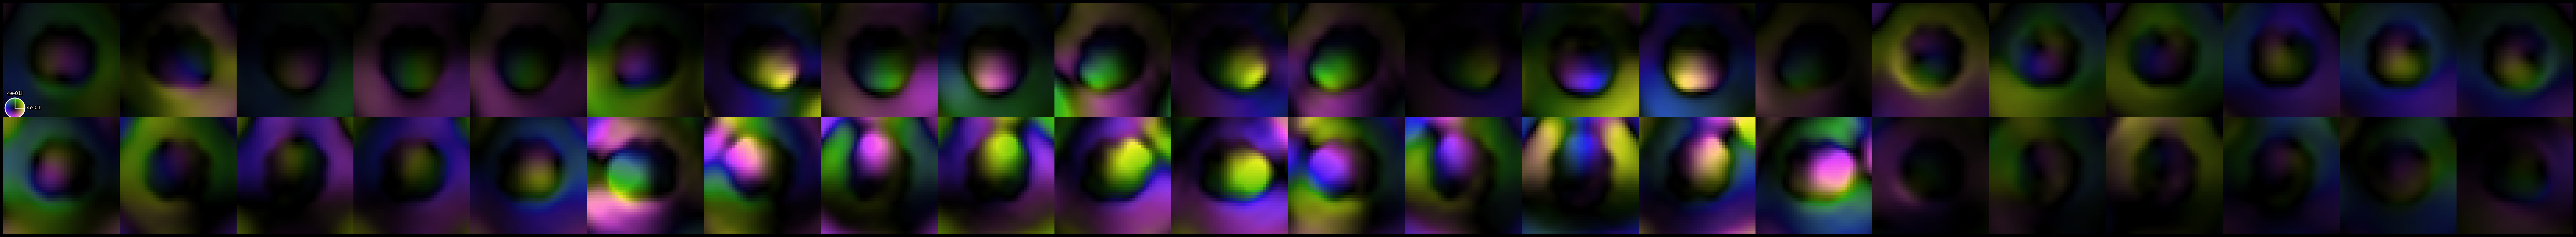

[10:28:25] [recon-lsq] Welcome to RIESLING
[10:28:25] [H5    ] Opened lores.h5 for reading id 72057594037927936
[10:28:25] [Traj  ] 3D Samples 37 Traces 16127 Matrix [42, 42, 42] FOV [252.00, 252.00, 252.00]
[10:28:26] [H5    ] Opened lores-ks.h5 for reading id 72057594037927937
[10:28:26] [Traj  ] Nominal FOV, matrix [42, 42, 42]
[10:28:26] [SENSE ] Normalizing to RSS
[10:28:26] [Kernel] Exponential Semi-Circle width 4 β 7.578488
[10:28:26] [Kernel] Width 4 Scale 1.892995e-09
[10:28:26] [Traj  ] Nominal FOV, matrix [42, 42, 42]
[10:28:26] [Traj  ] Nominal matrix [42, 42, 42] grid matrix [54, 54, 54] over-sampling [1.29, 1.29, 1.29]
[10:28:26] [Traj  ] 596699 valid, 0 invalid, 0 outside
[10:28:26] [Traj  ] Nominal FOV, matrix [42, 42, 42]
[10:28:26] [Kernel] Exponential Semi-Circle width 4 β 7.578488
[10:28:26] [Kernel] Width 4 Scale 1.892995e-09
[10:28:26] [Apodiz] Shape [42, 42, 42] Grid shape [54, 54, 54] Scale 272.1911
[10:28:26] [NUFFT ] ishape [42, 42, 42, 1, 44] oshape [44, 37, 

In [3]:
data = 'hires'
!riesling downsamp --res=6,6,6 --trim {data}.h5 lores.h5 -v2
!riesling sense-calib {data}.h5 {data}-ks.h5 -v2
data='lores'
#!riesling sense-maps {data}-ks.h5 {data}.h5 {data}-sm.h5 -v2
#rlp.plot.traj2d(f'{data1}.h5', sample=slice(0,-1,8), color='sample')

rlp.plot.traj2d(f'{data}.h5', sample=slice(0,-1,8), color='sample')
display(rlp.plot.sense(f'{data}-sm.h5',rows=2,rotates=1))

!riesling recon-lsq --precon-p=1 --sense="{data}-ks.h5" "{data}.h5" "{data}-lsq.h5" -v2


In [ ]:
data = 'hires'
!riesling op-nufft --adj {data}.h5 {data}-nufftadj.h5 -v2
data = 'lores'
!riesling op-nufft --adj {data}.h5 {data}-nufftadj.h5 -v2

In [ ]:
data = 'hires'
!riesling op-nufft {data}.h5 {data}-nufft.h5 -v2
data = 'lores'
!riesling op-nufft {data}.h5 {data}-nufft.h5 -v2

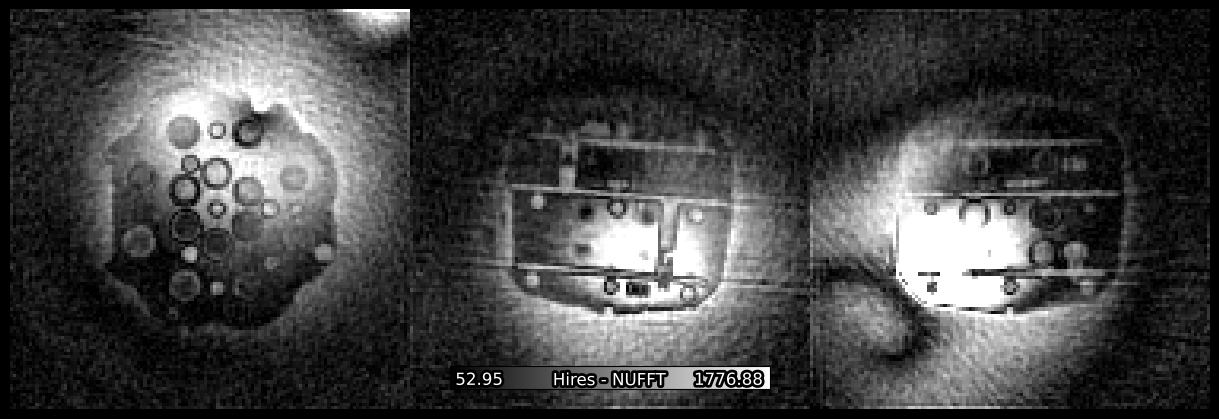

In [8]:
rlp.plot.planes(f'{data}-nufft.h5', title='Lores - NUFFT')

rlp.plot.planes('hires-nufft.h5', title='Hires - NUFFT')

In [9]:
lowres = 'lores'
coorlowres = rlp.io.read_trajectory(f'{lowres}.h5')
coorlowres = np.asarray(coorlowres)
kspacelowres = rlp.io.read_data(f'{lowres}.h5')
kspacelowres = np.asarray(kspacelowres)
kspacelowres = kspacelowres[0, 0] 
kspacelowres = np.moveaxis(kspacelowres, -1, 0)



hires = 'hires'
coorhires = rlp.io.read_trajectory(f'{hires}.h5')
coorhires = np.asarray(coorhires)
kspacehires = rlp.io.read_data(f'{hires}.h5')
kspacehires = np.asarray(kspacehires)
kspacehires = kspacehires[0, 0] 
kspacehires = np.moveaxis(kspacehires, -1, 0)

In [10]:
print(coorlowres.shape)

print(coorhires.shape)

print(f'kspace low res {kspacelowres.shape}')
print(f'kspace high res {kspacehires.shape}')

(16127, 37, 3)
(16128, 122, 3)
kspace low res (44, 16127, 37)
kspace high res (44, 16128, 122)


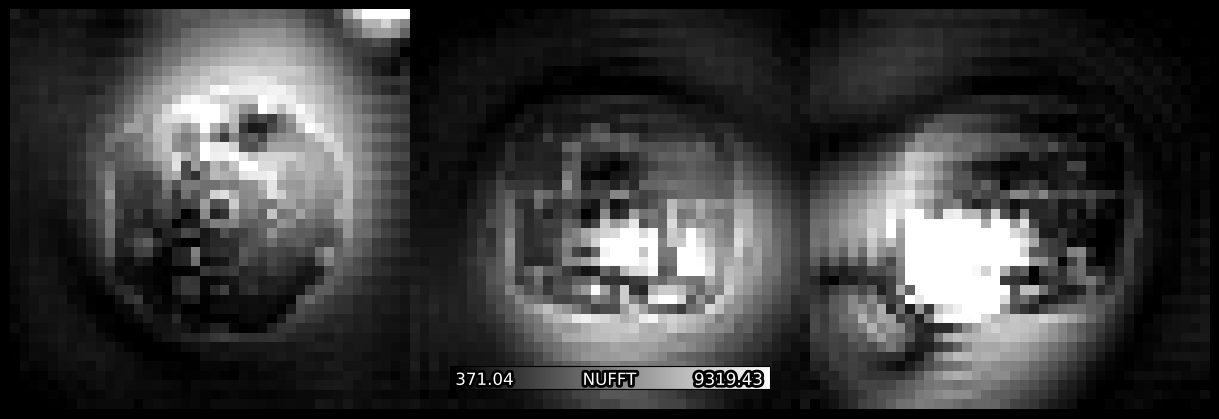

In [11]:
data = 'lores'
#!riesling downsamp --res=6,6,6 --trim {data}.h5 lores.h5 -v2
#!riesling op-nufft {data}.h5 {data}-nufft.h5 -v2

rlp.plot.planes('lores-nufft.h5', title='NUFFT')

In [12]:
dcf_new = np.sqrt(coorlowres[...,0]**2 + coorlowres[...,1]**2 + coorlowres[...,2]**2)

zte_im_grid = sp.nufft_adjoint(kspacelowres* dcf_new, coorlowres)
gridded_data = sp.fft(zte_im_grid, axes=(-2, -1))
#zte_im = np.sum(np.abs(zte_im_grid)**2, axis=0)**0.5

In [13]:
import h5py
def h5tonum(file, showshape=False):
    with h5py.File(file) as f:     
        d = f['data'][:]             
        traj = f['trajectory'][:]
        d = d[0,:,0]
        traj = np.moveaxis(traj,-1,0)
        if showshape == True:
            print(d.shape)
            print(traj.shape)
    return d, traj

d, traj = h5tonum('hires-nufft.h5', showshape=True)
d_ksp = sp.fft(d)

(44, 126, 126, 126)
(3, 16128, 122)


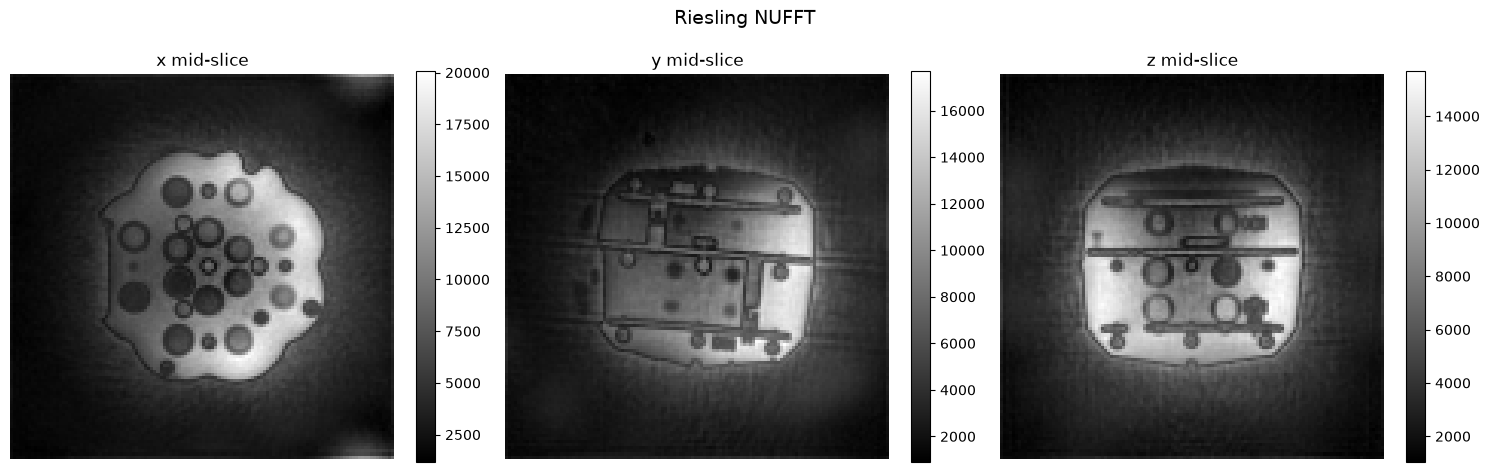

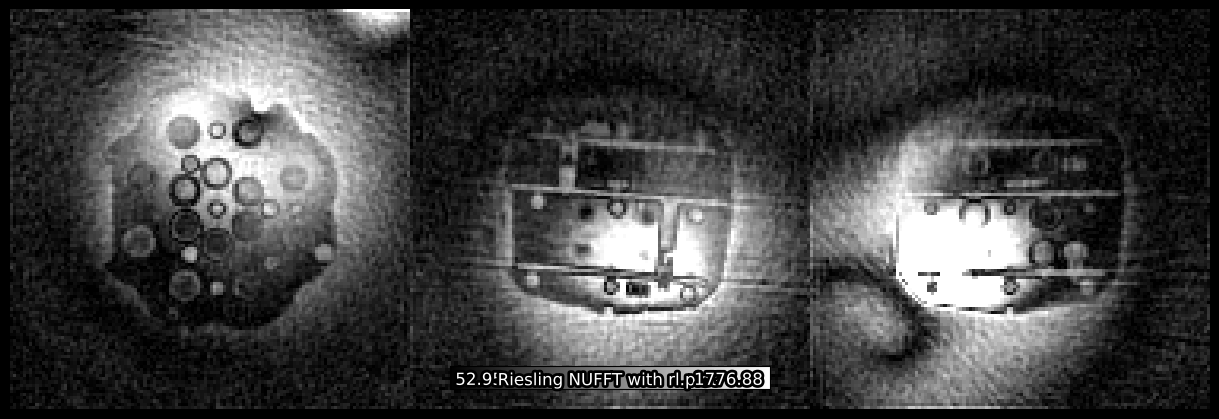

In [14]:
riesling_im = d

riesling_sp_imgrid = np.sum(np.abs(riesling_im)**2, axis=0)**0.5

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Riesling NUFFT', fontsize=14)
nx, ny, nz = riesling_sp_imgrid.shape
for ax, (sl, title) in zip(axes, [
    (riesling_sp_imgrid[nx // 2, :, :], 'x mid-slice'),
    (riesling_sp_imgrid[:, ny // 2, :], 'y mid-slice'),
    (riesling_sp_imgrid[:, :, nz // 2], 'z mid-slice'),
]):
    im = ax.imshow(np.abs(sl), cmap='gray')
    ax.set_title(title)
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046)
#fig.savefig('riesling_recon.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


rlp.plot.planes('hires-nufft.h5', title='Riesling NUFFT with rl.plot')

## Goal of the notebook

### Integrate riesling into sigpy pipeline

1. Start with NUFFT inverse

- get the above file format into something that riseling can read

In [5]:
def zeropadding3d(cart_kspace,resize_factor):
    resize = cart_kspace.shape[1]*resize_factor
    n_coils = cart_kspace.shape[0]
    image_grid = sp.ifft(cart_kspace)
    enlarged_image_grid = sp.resize(image_grid, [n_coils,resize, resize, resize])
    enlarged_cartesian_kspace = sp.fft(enlarged_image_grid, axes=(-2, -1))
    return enlarged_cartesian_kspace

In [15]:
enlarged_cartesian = zeropadding3d(gridded_data, resize_factor=2)
enlarged_cartesian = zeropadding3d(enlarged_cartesian, resize_factor=2)

In [16]:
enlarged_cartesian.shape

(44, 160, 160, 160)

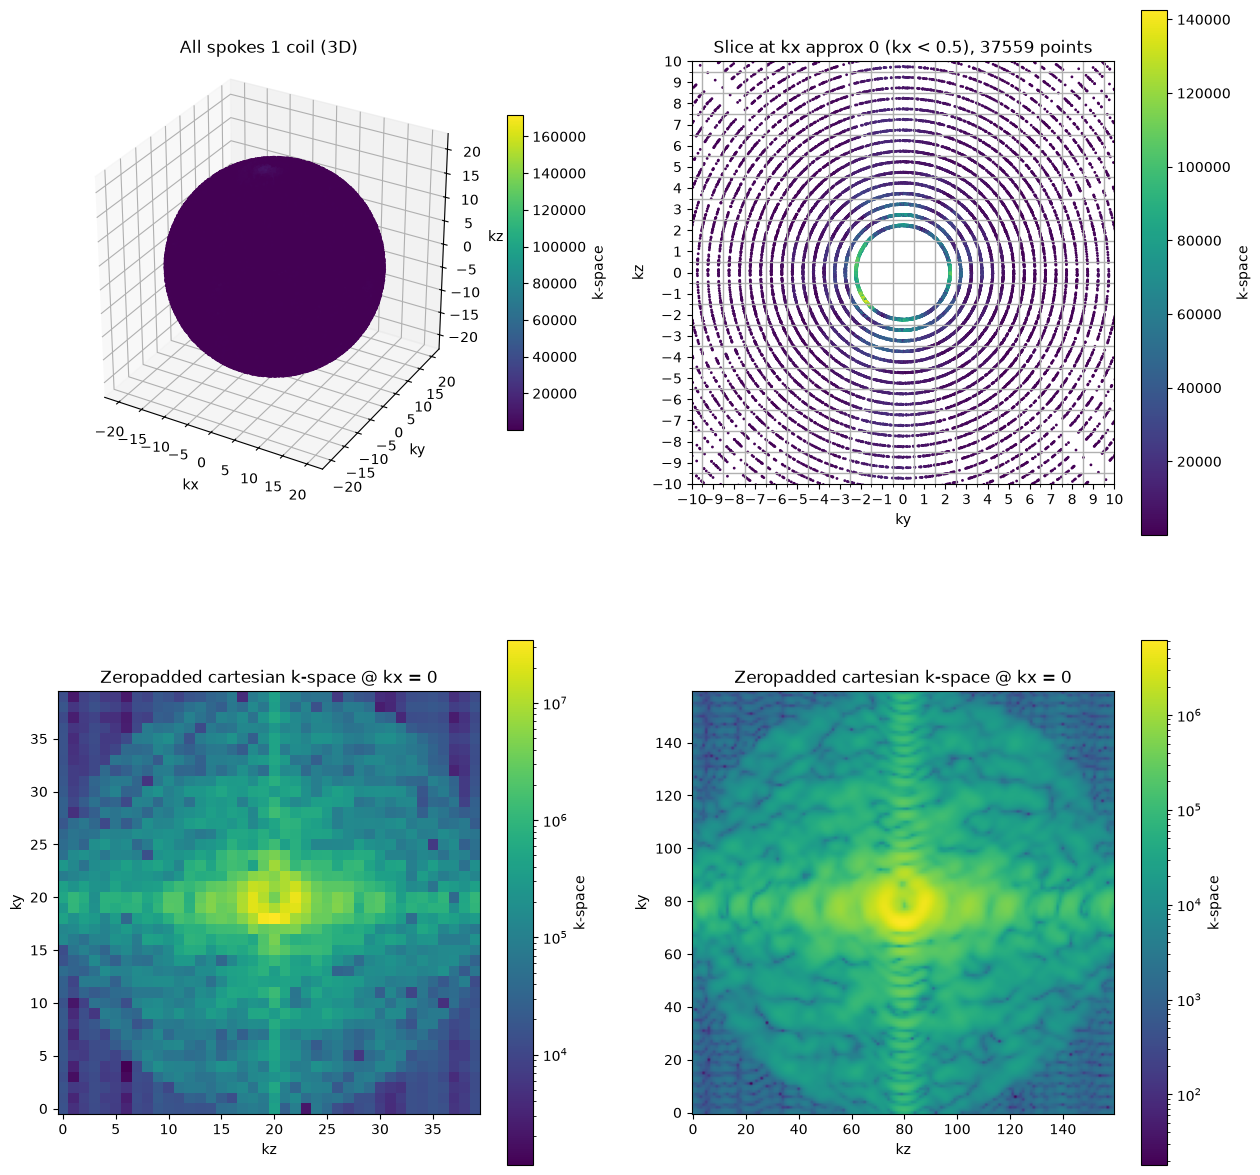

In [17]:
import matplotlib
#all_coords = zte_radial_coords.reshape(-1,2)
#all_kspace = zte_radial_kspace[0].reshape(-1)

all_ztecoords= coorlowres.reshape(-1,3)
all_zteksp = kspacelowres.reshape(-1)


fig = plt.figure(figsize=(15,15))

# --- Subplot 1: full 3D trajectory ---
ax0 = fig.add_subplot(2, 2, 1, projection='3d')
im0 = ax0.scatter(
    all_ztecoords[:, 0], all_ztecoords[:, 1], all_ztecoords[:, 2],
    c=np.abs(kspacelowres[0]).reshape(-1),
    s=1
)
ax0.set_title('All spokes 1 coil (3D)')
ax0.set_xlabel('kx')
ax0.set_ylabel('ky')
ax0.set_zlabel('kz')
ax0.set_box_aspect((1, 1, 1))
fig.colorbar(im0, ax=ax0, label='k-space', shrink=0.6)

# --- Subplot 2: slice near kx = 0 (2D view of ky-kz plane) ---
ax1 = fig.add_subplot(2, 2, 2)  

tol = 0.5  # slab half-thickness; adjust to your coordinate units
maskztevis = np.abs(all_ztecoords[:, 0]) < tol

im1 = ax1.scatter(
    all_ztecoords[maskztevis, 1], all_ztecoords[maskztevis, 2],
    c=np.abs(kspacelowres[0]).reshape(-1)[maskztevis],
    s=1
)
ax1.set_title(f'Slice at kx approx 0 (kx < {tol}), {maskztevis.sum()} points')
ax1.set_xlabel('ky')
ax1.set_ylabel('kz')
ax1.set_aspect('equal')
ax1.xaxis.set_major_locator(plt.MultipleLocator(1))
ax1.yaxis.set_major_locator(plt.MultipleLocator(1))
ax1.grid(visible=True, which='minor', linewidth=1)
ax1.xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax1.yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax1.set_xlim(-10,10)
ax1.set_ylim(-10,10)
#ax1.axis('equal')
fig.colorbar(im1, ax=ax1, label='k-space')

ax2 = fig.add_subplot(2, 2, 3)

grid_vol = np.abs(gridded_data[0])
kx_centre = grid_vol.shape[0] // 2  # kx = 0 lives at the centre index

im2 = ax2.imshow(
    grid_vol[kx_centre],
    origin='lower',
    norm=matplotlib.colors.LogNorm()  # k-space dynamic range is huge
)
ax2.set_title('Zeropadded cartesian k-space @ kx = 0')
ax2.set_xlabel('kz')
ax2.set_ylabel('ky')
fig.colorbar(im2, ax=ax2, label='k-space')

ax2 = fig.add_subplot(2, 2, 4)

grid_vol_zeropadding = np.abs(enlarged_cartesian[0])
kx_centre_large = grid_vol_zeropadding.shape[0] // 2  # kx = 0 lives at the centre index

im2 = ax2.imshow(
    grid_vol_zeropadding[kx_centre_large],
    origin='lower',
    norm=matplotlib.colors.LogNorm()  # k-space dynamic range is huge
)
ax2.set_title('Zeropadded cartesian k-space @ kx = 0')
ax2.set_xlabel('kz')
ax2.set_ylabel('ky')
fig.colorbar(im2, ax=ax2, label='k-space')
plt.show()


In [18]:
width=4
gap = 3
num_iters = 50


inner_wid=20
indiv2 = int(inner_wid/2)

In [19]:
def inner_portion(enlarged_kspace, inner_sidelen):
    """Take an inner square of kspace to speed up the hankel loop

        Args:
            enlarged_kspace: Zero padded kspace in cartesian coordinates (n_coils, nx, ny)
            inner_sidelen: Side legnth of the inner square, divided by 2 to find from central point outward

        Returns:
            isolated_kspace: Inner kspace array
            isolation_mask: Mask of the inner region to use when 'jigsawing' the transformed array back in
            Start: xy index of the enlarged array that the inner region starts at
            End: xy index of the enlarged array that the inner region ends at
    """
    cx, cy, cz = enlarged_kspace.shape[1] // 2, enlarged_kspace.shape[2] // 2, enlarged_kspace.shape[3] // 2
    N = inner_sidelen/2
    start, end = int(cx-N), int(cx+N)
    isolation_mask = np.ones(enlarged_kspace.shape[1:], dtype=int)
    isolation_mask[start:end, start:end, start:end] = 0
    isolated_kspace = enlarged_kspace[:, start:end, start:end, start:end]
    
    return(isolated_kspace, isolation_mask, start, end)

inner_region, inner_mask, start, end = inner_portion(enlarged_kspace=enlarged_cartesian, inner_sidelen=inner_wid)

In [30]:
grid_vol_zeropadding = np.abs(enlarged_cartesian[0])
kx_centre_large = grid_vol_zeropadding.shape[0] // 2


cy = cx = cz = inner_wid // 2
r = 3  # radius in pixels; adjust to cover the gap
yy, xx, zz = np.ogrid[:inner_wid, :inner_wid, :inner_wid]
mask = (yy - cy)**2 + (xx - cx)**2 + (zz - cz)**2 > r**2 + 2

mask[(cy-3):(cy+4), cx, cz] = False   # line along axis 0
mask[cy, (cx-3):(cx+4), cz] = False   # line along axis 1
mask[cy, cx, (cz-3):(cz+4)] = False


'''masked_inner = inner_region.copy()
masked_inner[:,~mask] = 0

inner_removed = inner_region.copy()
inner_removed[:,mask] = 0

totalwid = 1024
totaldiv = totalwid // 2

mask2 = np.ones((totalwid, totalwid), dtype=bool)

mask2[(indiv2-3):(indiv2+3), indiv2:indiv2+1] = False
mask2[(indiv2), (indiv2-2):(indiv2+3)] = False'''


#asm.plot_mask(inner_region, mask=mask, zte_radial_coords=all_ztecoords, zte_radial_kspace=kspacelowres, innersidelen=inner_wid,sidelencart=10,sidelenrad=4)

isolated_kspace = inner_region
innersidelen=inner_wid
sidelencart = 10
zte_radial_kspace = kspacelowres
sidelenrad = 10

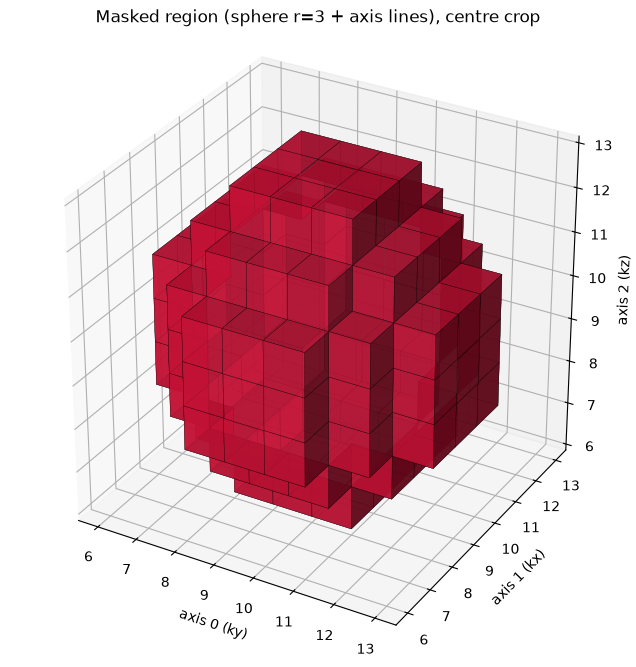

In [28]:
import matplotlib.pyplot as plt

pad = 3*r
sl = slice(cy - pad, cy + pad)
region = ~mask[sl, sl, sl]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
ax.voxels(region, facecolors='crimson', edgecolor='k', linewidth=0.2, alpha=0.8)
ax.set_xlabel('axis 0 (ky)')
ax.set_ylabel('axis 1 (kx)')
ax.set_zlabel('axis 2 (kz)')
ax.set_title(f'Masked region (sphere r={r} + axis lines), centre crop')
ax.set_box_aspect((1, 1, 1))
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


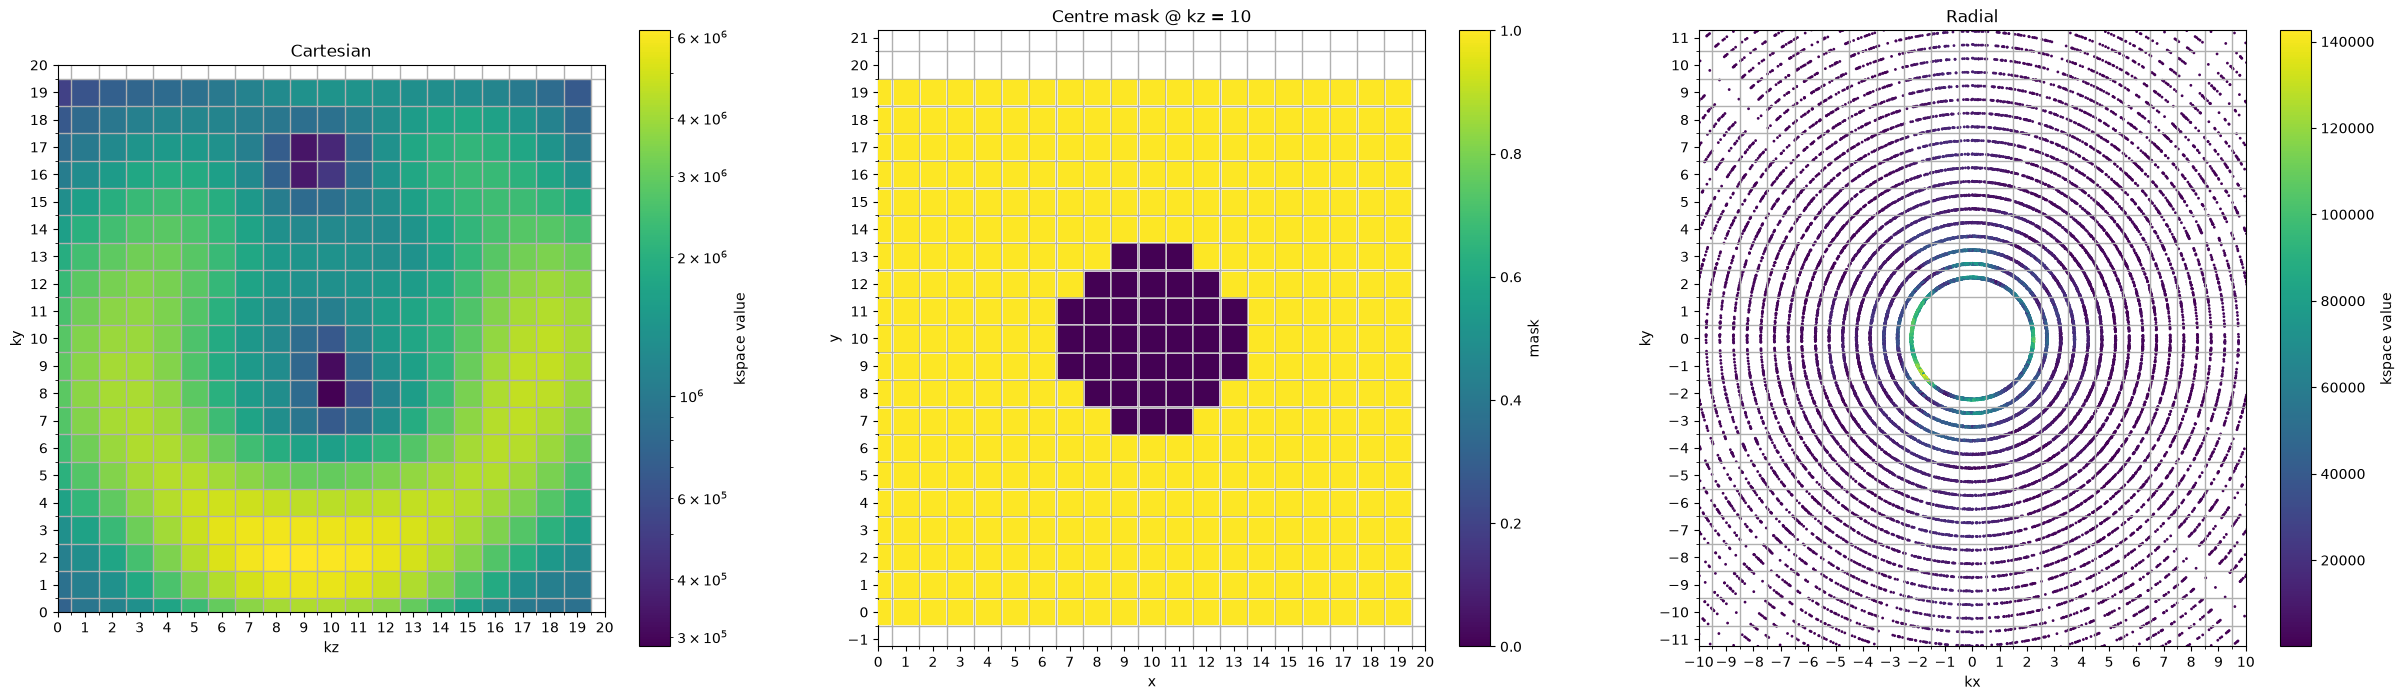

In [31]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 8))

grid_vol_zeropadding = np.abs(inner_region[0])
kx_centre_large = grid_vol_zeropadding.shape[0] // 2


im = ax[0].imshow(
    np.abs(grid_vol_zeropadding[kx_centre_large]),
    origin='lower',
    norm=matplotlib.colors.LogNorm(),
)
fig.colorbar(im, ax=ax[0], label='kspace value')
ax[0].set_title('Cartesian')
ax[0].set_xlabel('kz')
ax[0].set_ylabel('ky')
ax[0].set_xlim(innersidelen/2 - sidelencart,innersidelen/2 + sidelencart)
ax[0].set_ylim(innersidelen/2 - sidelencart,innersidelen/2 + sidelencart)
ax[0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0].grid(visible=True, which='minor', linewidth=1)
ax[0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[0].yaxis.set_major_locator(plt.MultipleLocator(1))


mask2d = mask[:, :, cz]          # central slice; pick the axis/index you care about

yy, xx = np.mgrid[0:mask2d.shape[0], 0:mask2d.shape[1]]
im1 = ax[1].scatter(xx.ravel(), yy.ravel(), c=mask2d.ravel().astype(int),
                    cmap='viridis', s=300, marker='s', zorder=3)
fig.colorbar(im1, ax=ax[1], label='mask')
ax[1].set_title(f'Centre mask @ kz = {cz}')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].axis('equal')

c = mask2d.shape[0] / 2
ax[1].set_xlim(c - sidelencart, c + sidelencart)
ax[1].set_ylim(c - sidelencart, c + sidelencart)

ax[1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1].grid(visible=True, which='minor', linewidth=1)
ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))



tol = 0.5  # slab half-thickness; adjust to your coordinate units
maskztevis = np.abs(all_ztecoords[:, 0]) < tol

im2 = ax[2].scatter(all_ztecoords[maskztevis, 1], all_ztecoords[maskztevis, 2],c=np.abs(kspacelowres[0]).reshape(-1)[maskztevis],s=1)
fig.colorbar(im2, ax=ax[2], label='kspace value')
ax[2].set_title('Radial')
ax[2].set_xlabel('kx')
ax[2].set_ylabel('ky')
ax[2].axis('equal')
ax[2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].grid(visible=True, which='minor', linewidth=1)
ax[2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].yaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].set_xlim(-10,10)
ax[2].set_ylim(-10,10)

plt.show()

In [26]:
def hankel(kspace, w):
    # kspace: (N_c, X, Y, Z)
    N_c = kspace.shape[0]
    N_x = kspace.shape[1] - w + 1
    N_y = kspace.shape[2] - w + 1
    N_z = kspace.shape[3] - w + 1
    data_matrix = []
    for c in range(N_c):
        onecoil_matrix = np.empty((w*w*w, N_x*N_y*N_z), dtype=np.complex64)
        col_index = 0
        for k in range(N_z):        # z outermost
            for i in range(N_y):
                for j in range(N_x):    # x innermost, matching your 2D ordering
                    mat = kspace[c, j:j+w, i:i+w, k:k+w]
                    onecoil_matrix[:, col_index] = mat.reshape(-1, order='F')
                    col_index += 1
        data_matrix.append(onecoil_matrix)
    return np.vstack(data_matrix), N_c, N_x, N_y, N_z


def hankel_H_averaged(data_matrix, n_coils, Nx, Ny, Nz, w=3):
    kspace = []
    split_arr = np.array(np.split(data_matrix, n_coils))

    n_win_x = Nx - w + 1
    n_win_y = Ny - w + 1
    n_win_z = Nz - w + 1

    for c in range(n_coils):
        singlecoil = split_arr[c]
        transposed = singlecoil.T          # one row per window

        recon = np.zeros((Nx, Ny, Nz), dtype=np.complex64)
        counts = np.zeros((Nx, Ny, Nz), dtype=np.float32)

        for index in range(len(transposed)):
            win = transposed[index].reshape((w, w, w), order='F')

            # invert col_index = k*(n_win_y*n_win_x) + i*n_win_x + j
            j = index % n_win_x                      # x offset (innermost)
            i = (index // n_win_x) % n_win_y         # y offset
            k = index // (n_win_x * n_win_y)         # z offset (outermost)

            recon[j:j+w, i:i+w, k:k+w] += win
            counts[j:j+w, i:i+w, k:k+w] += 1

        kspace.append(recon / counts)
    return np.array(kspace)

In [27]:
def softimpute_ALS_time(X_H, M_H, rank, lamda, n_iters):
    I = np.eye(rank)
    m, n = np.shape(X_H)
    U = np.random.randn(m, rank) + 1j * np.random.randn(m, rank)
    V = np.random.randn(n, rank) + 1j * np.random.randn(n, rank)
    print(f'reached D  t={time.perf_counter():.6f}')
    D = I.copy()

    A = np.dot(U, D)
    B = np.dot(V, D)
    print(f'iter_count  t={time.perf_counter():.6f}')
    iter_count = 0
    ABt = A @ B.conj().T
    print(f'reached Abt  t={time.perf_counter():.6f}')
    iter_times = []
    t_total_start = time.perf_counter()

    while iter_count < n_iters:
        t_start = time.perf_counter()

        X_star = np.where(M_H, X_H, ABt)
        print(f'reached A  dt={time.perf_counter() - t_start:.6f}')
        A = X_star @ B @ np.linalg.inv(B.conj().T @ B + lamda*I)
        print(f'reached Abt 2  dt={time.perf_counter() - t_start:.6f}')
        ABt = A @ B.conj().T
        print(f'reached X_star  dt={time.perf_counter() - t_start:.6f}')
        X_star = np.where(M_H, X_H, ABt)
        print(f'reached B  dt={time.perf_counter() - t_start:.6f}')
        B = X_star.conj().T @ A @ np.linalg.inv(A.conj().T @ A + lamda*I)
        print(f'reached ABt 3  dt={time.perf_counter() - t_start:.6f}')
        ABt = A @ B.conj().T
        iter_count += 1

        t_elapsed = time.perf_counter() - t_start
        iter_times.append(t_elapsed)

    t_total = time.perf_counter() - t_total_start
    t_mean = np.mean(iter_times)

    return (ABt, t_total, t_mean, iter_times)




def LORAKS_imputeals(n_iters, window_size, cartesian_inputkspace, dtg_mask, rank, lamda, cartesian_grid, inner_mask, inner_start, inner_end):
    ### NOTE: In this version, cartesian_grid is the original zte cart grid, needed here as no zeropadding
    ksp_forhankel = cartesian_inputkspace.copy()
    ksp_forhankel = ksp_forhankel * dtg_mask
    hankel_matrix, *_  = hankel(kspace=ksp_forhankel, w=window_size)
    masked_hankel = np.broadcast_to(dtg_mask, (cartesian_inputkspace.shape))
    masked_hankel, *_ = hankel(kspace=masked_hankel, w=window_size)
    masked_hankel = np.real(masked_hankel) > 0.5
    print('hankel done')
    
    
    filled_hankel, *_ = softimpute_ALS_time(X_H = hankel_matrix, M_H = masked_hankel, rank = rank, lamda = lamda, n_iters=n_iters)

    kspace_cart_coils_recon = hankel_H_averaged(filled_hankel, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], Nz=ksp_forhankel.shape[3],w=window_size)
    kspace_cart_coils_recon = np.where(dtg_mask, cartesian_inputkspace, kspace_cart_coils_recon)
    filled_ksp = asm.jigsaw3d(output_kspace=kspace_cart_coils_recon, isolation_mask = inner_mask, start=inner_start, end=inner_end, enlarged_kspace=cartesian_grid)

    return (filled_ksp)

In [20]:
import time

timings = {'als': [], 'svd': []}
t0 = time.perf_counter()
output_kspaceals,*_ = LORAKS_imputeals(n_iters=1, window_size=10, cartesian_inputkspace=inner_region,dtg_mask=mask, rank= 10, lamda = 5*10**-5, cartesian_grid = enlarged_cartesian, inner_mask = inner_mask, inner_start = start, inner_end = end)
t1 = time.perf_counter()
timings['als'].append(t1 - t0)

print(f"Als done in {t1-t0}")

#t2 = time.perf_counter()
#ims_svd, output_kspacesvd, deltas, svdtimes, hankelshape = LORAKS_loop_timing(n_iters=2, window_size=5, zero_thresh=0.2,cartesian_inputkspace=inner_region, dtg_mask=mask, im_dim=256)
#t3 = time.perf_counter()
#timings['svd'].append(t3-t2)

#print(f"SVD done in {t3-t2}")

hankel done
reached D  t=12040.160588
iter_count  t=12040.163314
reached Abt  t=12041.266879
reached A  dt=7.484084
reached Abt 2  dt=8.703331
reached X_star  dt=12.052134
reached B  dt=26.831106
reached ABt 3  dt=31.832894
Als done in 42.47834779200093
